# Recinos Entities

# Set up Environment

In [1]:
import pandas as pd
import numpy as np
from unidecode import unidecode

In [2]:
OHCO = ['parte','capit']

# Import model

In [3]:
SPACY = pd.read_pickle("spacy.pickle")

# Extract Entities

In [4]:
ENT_RAW = SPACY.apply(lambda x: [ent for ent in x.ents])\
    .apply(pd.Series).stack().to_frame('ent_tup')

In [5]:
ENT_RAW.index.names = OHCO + ['ord']
ENT_RAW['ent_str'] = ENT_RAW.ent_tup.apply(lambda x: ' '.join(map(str, x)))
ENT_RAW = ENT_RAW.drop('ent_tup', axis=1)

In [6]:
ENT_RAW['ent_str_norm'] = ENT_RAW.ent_str.str.upper()\
    .str.replace(r"\W+", "", regex=True)\
    .str.strip()\
    .apply(unidecode)

# Define Non-Entities

This are false positives from Spacy's NER.

In [229]:
NONENTITIES = {'A', 'ACA', 'ACONTINUACION', 'ASI', 'ASIPUES', 'ALPUNTO', 'AHORA', 'ANDA', 'BUENO', 'DEESTAMANERA', 
               'ENVERDAD', 'GRANDE', 'NO', 'NOOSAFLIJAIS', 'NOSOTROS', 'SEREIS', 'SOLO', 'SINEMBARGO', 'VERDADERAMENTE', 'VAMONOS'}

In [230]:
ENT = ENT_RAW[~ENT_RAW.ent_str_norm.isin(NONENTITIES)]

# Extract Entity Types

In [9]:
ENT_TYPE = ENT.ent_str_norm.value_counts().to_frame('n')
ENT_TYPE['p'] = ENT_TYPE.n / ENT_TYPE.n.sum()
ENT_TYPE['i'] = np.log2(1/ENT_TYPE.p)
ENT_TYPE['h'] = ENT_TYPE.p * ENT_TYPE.i

# Create Bag of Entities

In [11]:
ENT_BOW = ENT.groupby(['parte','capit','ent_str_norm']).ent_str_norm.count().to_frame('n') 

In [12]:
ENT_BOW.head()

n
parte capit ent_str_norm      
0     1     ABUELAYELABUELO  1
            AHRAXALAC        1
            AHRAXATZEL       1
            ALOM             1
            BITOL            1

# CCC

In [232]:
def create_ccc():
    X = ENT_BOW.reset_index()
    CCC = X.merge(X, on=OHCO)[['ent_str_norm_x', 'ent_str_norm_y']].query("ent_str_norm_x < ent_str_norm_y").value_counts().to_frame('n')
    PAIRS = CCC[CCC.n > 3]
    PAIRS.index.names = ['x', 'y']
    NODES = []
    for a, b in PAIRS.index:
        NODES.append(a)
        NODES.append(b)
    NODES = "\n".join(list(set(NODES)))
    EDGES = "\n".join([f"{x} -- {y} [weight={n}]" for x, y, n in PAIRS.reset_index().values])
    GRAPH = "\n\n".join(["graph G {", NODES, EDGES, "}"])
    with open("ccc-graph.dot", "w") as outfile:
        outfile.write(GRAPH)
create_ccc()

# Create Entity Co-cccurence Matrix

In [13]:
ENT_M = ENT_BOW.unstack(fill_value=0)

In [14]:
ENT_M.columns = ENT_M.columns.droplevel(0)

In [15]:
ENT_M.head()

ent_str_norm  ABUELAYELABUELO  ABUNDANCIA  ACATUGLORIA  ACHACLBOY  ACLARE  \
parte capit                                                                 
0     1                     1           0            0          0       0   
1     1                     0           0            0          0       0   
      2                     0           0            0          0       1   
      3                     0           0            0          0       0   
      4                     0           0            0          0       0   

ent_str_norm  ACOMPANADNOS  ACONTINUACIONCADAUNOTOMOY  \
parte capit                                             
0     1                  0                          0   
1     1                  0                          0   
      2                  0                          0   
      3                  0                          0   
      4                  0                          0   

ent_str_norm  ACONTINUACIONENTRARONENPLATICASACERCADELACREACION  \
parte capit                                                       
0     1                                                       0   
1     1                                                       0   
      2                                                       0   
      3                                                       0   
      4                                                       0   

ent_str_norm  ACONTINUACIONLESPREGUNTO  ACONTINUACIONSEPUSOENCAMINOELLASOLA  \
parte capit                                                                   
0     1                              0                                    0   
1     1                              0                                    0   
      2                              0                                    0   
      3                              0                                    0   
      4                              0                                    0   

ent_str_norm  ...  ZAQUINIMAC  ZAQUINIMATZIIS  ZAQUIRIBALPATOFRI  ZAQUITOC  \
parte capit   ...                                                            
0     1       ...           0               1                  0         0   
1     1       ...           0               0                  0         0   
      2       ...           0               0                  0         0   
      3       ...           0               0                  0         0   
      4       ...           0               0                  0         0   

ent_str_norm  ZAQUIYA  ZIPACNA  ZIYAHA  ZOTZIHA  ZOTZU  ZUIVA  
parte capit                                                    
0     1             0        0       0        0      0      0  
1     1             0        0       0        0      0      0  
      2             0        0       0        0      0      0  
      3             0        0       0        0      0      0  
      4             0        0       0        0      0      0  

[5 rows x 1165 columns]

# Visualize Over Narrative Time

In [16]:
def plot_char(*ent_names):
    title = ", ".join(ent_names)
    legend = len(ent_names) == 2
    if len(ent_names) > 1:
        corr = ENT_M[list(ent_names)].corr('kendall').iloc[0,1]
        title += f" (r = {round(corr, 2)})"
    ENT_M[list(ent_names)].plot.bar(figsize=(10,2), rot=90, title=title, legend=legend); 

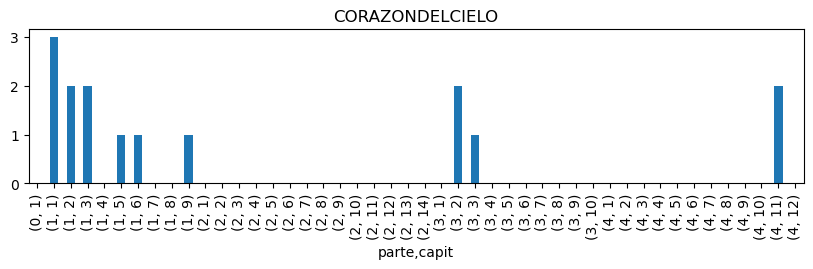

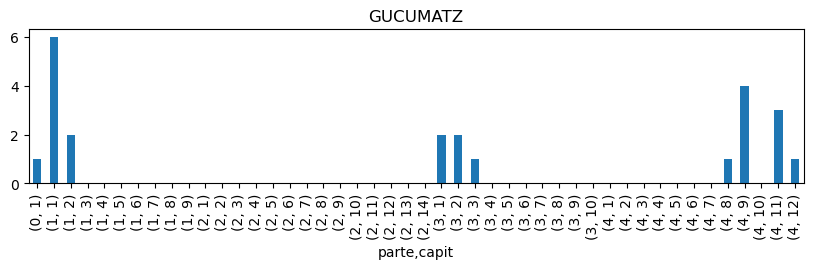

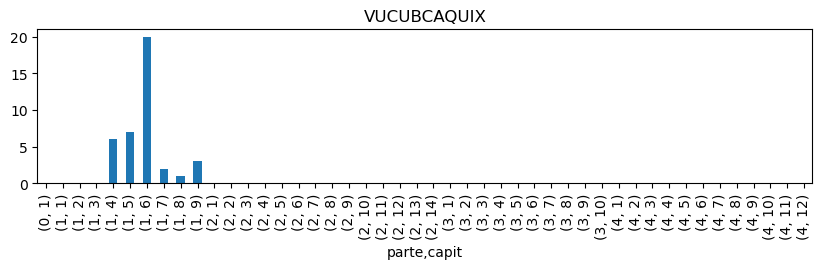

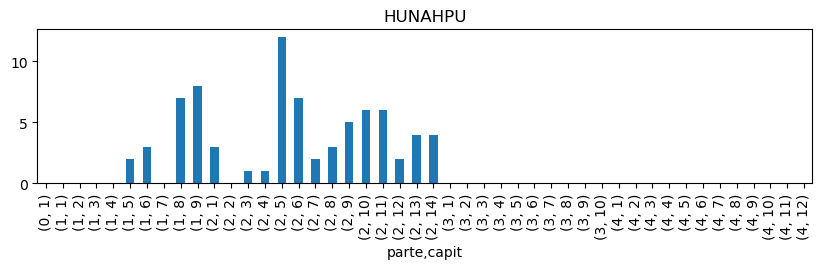

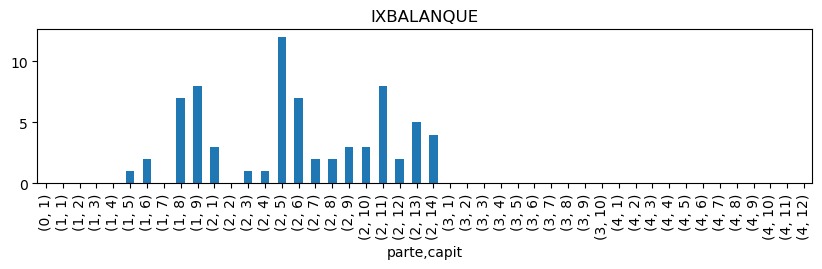

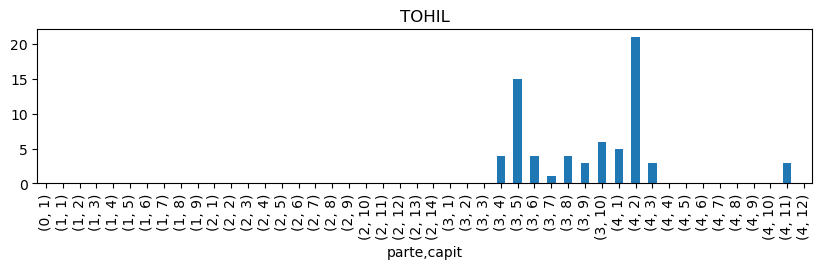

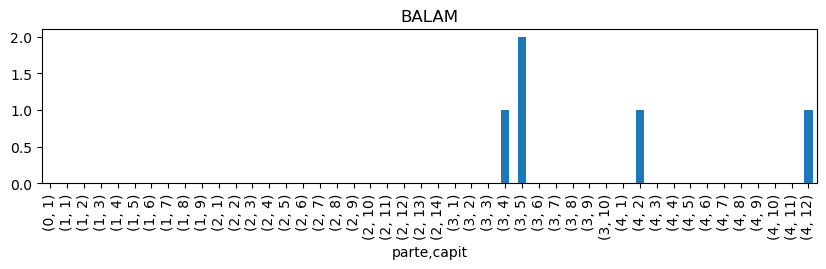

In [17]:
for name in "corazondelcielo gucumatz vucubcaquix hunahpu ixbalanque tohil balam".split():
    plot_char(name.upper())

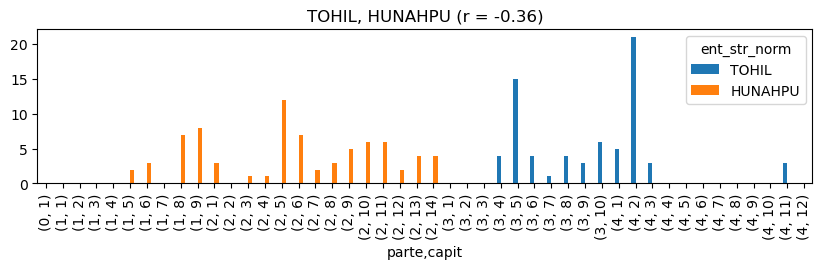

In [18]:
plot_char('TOHIL', 'HUNAHPU')

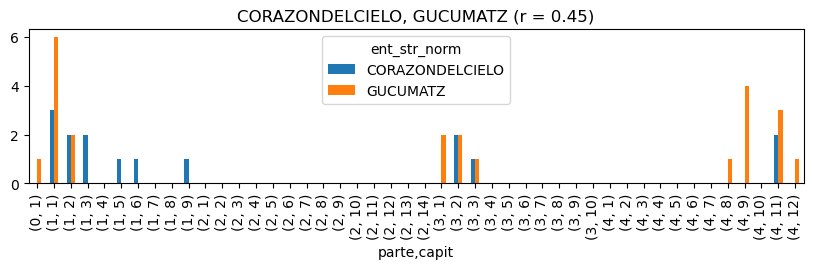

In [19]:
plot_char('CORAZONDELCIELO', 'GUCUMATZ')

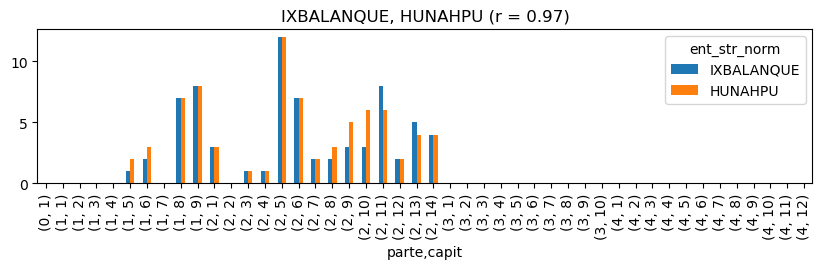

In [20]:
plot_char('IXBALANQUE', 'HUNAHPU')

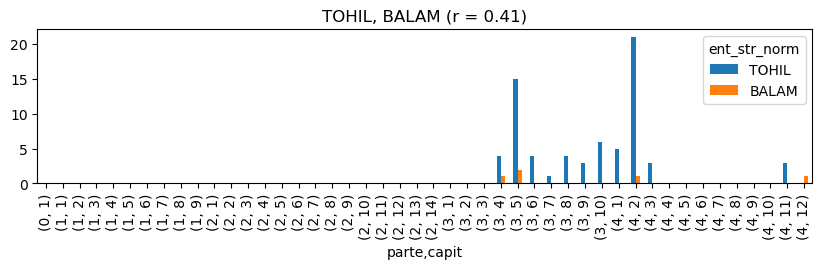

In [21]:
plot_char('TOHIL', 'BALAM')

# Compute Entity DFIDF

In [22]:
ENT_TYPE['df'] = ENT_M.astype(bool).sum()

In [23]:
ENT_TYPE['dfidf'] = ENT_TYPE.df * np.log2(len(ENT_M)/ENT_TYPE.df)

In [43]:
ENT_TYPE.sort_values('dfidf', ascending=False).head(20)

,n,p,i,h,df,dfidf
ent_str_norm,,,,,,
HUNAHPU,76,0.028799,5.117848,0.147388,17,24.413685
IXBALANQUE,71,0.026904,5.216029,0.140333,17,24.413685
XIBALBA,91,0.034483,4.857981,0.167517,16,24.376991
BALAMQUITZE,54,0.020462,5.610888,0.114812,16,24.376991
MAHUCUTAH,50,0.018947,5.721919,0.108411,16,24.376991
SENORES,92,0.034862,4.842214,0.168808,18,24.365465
BALAMACAB,48,0.018189,5.780813,0.105146,15,24.250070
IQUIBALAM,35,0.013263,6.236493,0.082712,14,24.026898
HACAVITZ,41,0.015536,6.008224,0.093345,14,24.026898


# Extract Significant Entities

In [44]:
A = ENT_TYPE.dfidf.quantile(.95)
B = ENT_TYPE.df.quantile(.95)

In [45]:
ENT_SIG = ENT_TYPE.loc[(ENT_TYPE.n >= B) & (ENT_TYPE.dfidf > A)].index.tolist()

In [46]:
len(ENT_TYPE), len(ENT_SIG)

(1165, 49)

# Correlate Significant Entities

In [128]:
ENT_CORR = ENT_M[ENT_SIG].corr('kendall').stack().to_frame('r')

In [129]:
ENT_CORR.index.names = ['ent_1', 'ent_2']

In [130]:
ENT_CORR = ENT_CORR.query("ent_1 < ent_2").query("r > .25").copy()

In [131]:
len(ENT_CORR)

246

In [132]:
ENT_CORR.sort_values('r', ascending=False)

,,r
ent_1,ent_2,
HUNBATZ,HUNCHOUEN,0.988506
HUNCAME,VUCUBCAME,0.982127
BALAMQUITZE,MAHUCUTAH,0.970896
HUNAHPU,IXBALANQUE,0.967590
BALAMACAB,MAHUCUTAH,0.957917
...,...,...
IQUIBALAM,TZIQUINAHA,0.260102
CORAZONDELATIERRA,IXMUCANE,0.258257
ORIENTE,QUICHE,0.257739


# Generate Corr Graph

In [228]:
NODES = '\n'.join(ENT_SIG)
EDGES = '\n'.join([f'{ent_1} -- {ent_2} [weight={round(r * 20)}]' for ent_1, ent_2, r in ENT_CORR.reset_index().values])
GRAPH = "\n\n".join(["graph G {", "/* NODES */", NODES, "/* EDGES */", EDGES, "}"])
with open("corr-graph.dot", "w") as outfile:
    outfile.write(GRAPH)

# Save

In [38]:
ENT.to_csv("recinos-ENT.csv", index=True)
ENT_TYPE.to_csv("recinos-ENT_TYPE.csv", index=True)
ENT_BOW.to_csv("recinos-ENT_BOW.csv", index=True)

In [107]:
objs = [obj for obj in dir() if 'ENT' in obj]

In [108]:
objs

['ENT',
 'ENT_BOW',
 'ENT_CORR',
 'ENT_M',
 'ENT_RAW',
 'ENT_SIG',
 'ENT_TYPE',
 'NONENTITIES']

In [116]:
# getattr('ENT', '_data')

In [118]:
# ENT.__dir__()